# Modeling Obesity Risk: The Role of Eating Habits and Physical Health   

## Business Problem Overview:
Obesity is a serious health concern that can lead to various physical problems and affect a person’s overall quality of life. As awareness grows, people are becoming more interested in understanding the factors that contribute to obesity and finding ways to predict its development.
The issue is especially troubling because obesity is closely linked to cardiovascular diseases, and many developing countries are starting to see a rise in these health challenges.

## Problem Statement:
The main aim of this project is to create a machine learning model that can predict obesity levels by analyzing factors like eating habits, physical condition, and other lifestyle elements. This could help identify at-risk individuals and promote healthier lifestyles.


## Dataset Summary

This dataset is used to estimate obesity levels in individuals from Mexico, Peru, and Colombia, based on their eating habits and physical conditions. It contains **17 attributes** and **2,111 records**, with the target variable labeled as **NObesity (Obesity Level)**. The target classes include:

- **Insufficient Weight**
- **Normal Weight**
- **Overweight Level I**
- **Overweight Level II**
- **Obesity Type I**
- **Obesity Type II**
- **Obesity Type III**

### **Data Collection**
- **Source**: Survey of **2,111 people aged 14 to 61 years**.
- **Data Characteristics**: Includes both categorical and numerical variables:
  - **8 Numerical Attributes**
  - **9 Categorical Attributes**

### **Attributes**
1. **Frequent consumption of high-caloric food** (Categorical)
2. **Frequency of consumption of vegetables** (Categorical)
3. **Number of main meals** (Numerical)
4. **Consumption of food between meals** (Categorical)
5. **Consumption of water daily** (Numerical)
6. **Consumption of alcohol** (Categorical)
7. **Calories consumption monitoring** (Categorical)
8. **Physical activity frequency** (Numerical)
9. **Time using technology devices** (Numerical)
10. **Transportation used** (Categorical)
11. **Gender** (Categorical)
12. **Age** (Numerical)
13. **Height** (Numerical)
14. **Weight** (Numerical)
15. **Family history with overweight** (Categorical)
16. **Smoke** (Categorical)

## **Project Relevance**
This dataset enables the classification of individuals into specific obesity levels, facilitating insights into the relationship between lifestyle habits and obesity. The data can be utilized to build machine learning models that predict obesity levels, which can aid in personalized health interventions and public health strategies.

## **Model Evaluation Metrics**

1. Time: Measures the computational time taken to train and test the model.

2. Accuracy: Proportion of correctly predicted instances out of the total instances. It provides an overall measure of how well the model performs.

3. Precision: Indicates the proportion of positive predictions that are actually correct, focusing on the accuracy of the positive class.

4. Recall: Represents the proportion of actual positives that are correctly identified by the model.

5. F1 Score: The harmonic mean of precision and recall, offering a balanced measure between the two, especially for imbalanced datasets.

6. Confusion Matrix: The confusion matrix is a performance measurement tool for classification models. It provides insights into true positives (TP), false positives (FP), true negatives (TN), and false negatives (FN).  
   - **Components**:  
     - **True Positive (TP)**: Correctly predicted positive cases.  
     - **False Negative (FN)**: Actual positives predicted as negative.  
     - **False Positive (FP)**: Actual negatives predicted as positive.  
     - **True Negative (TN)**: Correctly predicted negative cases.  
     
### Purpose of Metrics
These metrics provide a comprehensive evaluation of the models' performance:
- **Accuracy** gives an overall performance score.
- **Precision** and **Recall** are critical for understanding how well the model handles imbalanced datasets.
- **Confusion Matrix** allows for detailed insight into the types of errors made by the model.
- **Total Time** helps assess the computational efficiency of each model.

Using these metrics, a comparative analysis of the models can be conducted to select the best-performing onebased on the task requirements.



## Importing the Data

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

The above code is used to mount your Google Drive to Google Colab, allowing you to access files stored in your Drive directly within the Colab environment. Once executed, it will prompt you to authenticate and grant permission to access your Drive. After successful authentication, the Drive will be mounted at /content/drive.

**Let's start by importing all the necessary libraries**

In [2]:
#importing all the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from warnings import filterwarnings
filterwarnings('ignore')

**Next, let's proceed by loading the dataset**

In [3]:
#importing data files
#file_path = '/content/drive/My Drive/MLProject/Obesity_data.csv'

#If want to import locally
file_path = 'Obesity_data.csv'
df = pd.read_csv(file_path)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
copy_df = df.copy()

**Dataset Summary and Structure**

In [5]:
df.shape

(2111, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [7]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

## Data Cleaning

**The dataset is preprocessed to enhance clarity and usability.**

Names of the columns are harder to interpret. so, to increase the readability we are renaming the columns. The renamed columns are mapped and printed for reference

### Renaming Columns

In [8]:
#Renaming columns for better readability
new_columns = ['Gender', 'Age', 'Height', 'Weight', 'Family_history_with_overweight', 'FCOHCF', 'FCOV', 'NMM', 'COFBM', 'Smoke', 'CH2O', 'Calorie_Consump_Monitoring', 'Physical_Activity_F', 'Time_using_techno_D', 'Consumption_Alc', 'MTRANS', 'NObesity']

In [9]:
for i, old_name, new_name in zip(range(1,len(new_columns)+1),df.columns, new_columns):
    print(f"{i}:::::::{old_name} -> {new_name}")

1:::::::Gender -> Gender
2:::::::Age -> Age
3:::::::Height -> Height
4:::::::Weight -> Weight
5:::::::family_history_with_overweight -> Family_history_with_overweight
6:::::::FAVC -> FCOHCF
7:::::::FCVC -> FCOV
8:::::::NCP -> NMM
9:::::::CAEC -> COFBM
10:::::::SMOKE -> Smoke
11:::::::CH2O -> CH2O
12:::::::SCC -> Calorie_Consump_Monitoring
13:::::::FAF -> Physical_Activity_F
14:::::::TUE -> Time_using_techno_D
15:::::::CALC -> Consumption_Alc
16:::::::MTRANS -> MTRANS
17:::::::NObeyesdad -> NObesity


In [10]:
df.columns = new_columns
df.head()

,Gender,Age,Height,Weight,Family_history_with_overweight,FCOHCF,FCOV,NMM,COFBM,Smoke,CH2O,Calorie_Consump_Monitoring,Physical_Activity_F,Time_using_techno_D,Consumption_Alc,MTRANS,NObesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   Family_history_with_overweight  2111 non-null   object 
 5   FCOHCF                          2111 non-null   object 
 6   FCOV                            2111 non-null   float64
 7   NMM                             2111 non-null   float64
 8   COFBM                           2111 non-null   object 
 9   Smoke                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  Calorie_Consump_Monitoring      2111 non-null   object 
 12  Physical_Activity_F             21

## Categorical and Numerical variables

This code helps differentiate between categorical and numerical variables in the dataset, which is essential for preprocessing steps like encoding categorical data or normalizing numerical data.

In [12]:
# Identify categorical variables
categorical_vars = df.select_dtypes(include='object').columns
num_categorical_vars = len(categorical_vars)
print("Categorical Variables: ")
print(categorical_vars)
print("\n")

# Identify numerical variables
numerical_vars = df.select_dtypes(include='number').columns
num_numerical_vars = len(numerical_vars)
print("Numerical Variables: ")
print(numerical_vars)
print("\n")

print("Number of categorical variables:", num_categorical_vars)
print("Number of numerical variables:", num_numerical_vars)

Categorical Variables: 
Index(['Gender', 'Family_history_with_overweight', 'FCOHCF', 'COFBM', 'Smoke',
       'Calorie_Consump_Monitoring', 'Consumption_Alc', 'MTRANS', 'NObesity'],
      dtype='object')


Numerical Variables: 
Index(['Age', 'Height', 'Weight', 'FCOV', 'NMM', 'CH2O', 'Physical_Activity_F',
       'Time_using_techno_D'],
      dtype='object')


Number of categorical variables: 9
Number of numerical variables: 8


## Exploratory Data Analysis

**Purpose of Data Exploration Metrics**

1. `df.describe()`: Provides a quick statistical summary to understand data distribution and spot anomalies.

2. Skewness: Measures the asymmetry of a distribution to check for skewed data.

3. Kurtosis: Indicates the tailedness of a distribution to assess the presence of outliers.

4. Box Plot: Visualizes the distribution of data, highlighting the median, quartiles, and potential outliers.

5. Count Plot: Displays the frequency distribution of categorical variables to highlight imbalances or trends in the data.


In [13]:
df.describe()

,Age,Height,Weight,FCOV,NMM,CH2O,Physical_Activity_F,Time_using_techno_D
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [14]:
#To know the skewness and kurtosis for each variable
numerical_df = df.select_dtypes(include='number')
skewness = numerical_df.skew()
kurtosis = numerical_df.kurtosis()

print(skewness)
print("\n")
print(kurtosis)

Age                    1.529100
Height                -0.012855
Weight                 0.255410
FCOV                  -0.432906
NMM                   -1.107097
CH2O                  -0.104912
Physical_Activity_F    0.498490
Time_using_techno_D    0.618502
dtype: float64


Age                    2.826389
Height                -0.562949
Weight                -0.699898
FCOV                  -0.637546
NMM                    0.385527
CH2O                  -0.879395
Physical_Activity_F   -0.620588
Time_using_techno_D   -0.548660
dtype: float64


In [15]:
df.describe(include=object)

,Gender,Family_history_with_overweight,FCOHCF,COFBM,Smoke,Calorie_Consump_Monitoring,Consumption_Alc,MTRANS,NObesity
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


Our target variable has 7 unique values, with Obesity_Type_I being the most common. <br>

The data shows more males than females and a higher number of non-smokers.<br>

Many people in the dataset have a family history of being overweight. <br>

In [16]:
print(df.isnull().sum())

Gender                            0
Age                               0
Height                            0
Weight                            0
Family_history_with_overweight    0
FCOHCF                            0
FCOV                              0
NMM                               0
COFBM                             0
Smoke                             0
CH2O                              0
Calorie_Consump_Monitoring        0
Physical_Activity_F               0
Time_using_techno_D               0
Consumption_Alc                   0
MTRANS                            0
NObesity                          0
dtype: int64


**Purpose of Counting Categories for Each Categorical Variable**

- **Understand Data Distribution**: Identifies the frequency of each category, revealing imbalances or dominant categories.
- **Spot Data Quality Issues**: Highlights unexpected or missing categories that may indicate errors.
- **Feature Engineering**: Guides encoding decisions and helps in merging rare categories or managing sparsity.
- **Model Insights**: Helps understand how categorical variables might influence model behavior, especially for imbalanced datasets.


In [17]:
#counts for each category for each categorical variable
for col in categorical_vars:
    #print(col)
    print(df[col].value_counts())
    print("\n")

Gender
Male      1068
Female    1043
Name: count, dtype: int64


Family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64


FCOHCF
yes    1866
no      245
Name: count, dtype: int64


COFBM
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64


Smoke
no     2067
yes      44
Name: count, dtype: int64


Calorie_Consump_Monitoring
no     2015
yes      96
Name: count, dtype: int64


Consumption_Alc
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64


MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64


NObesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64




**Histograms for each continuous varibles**

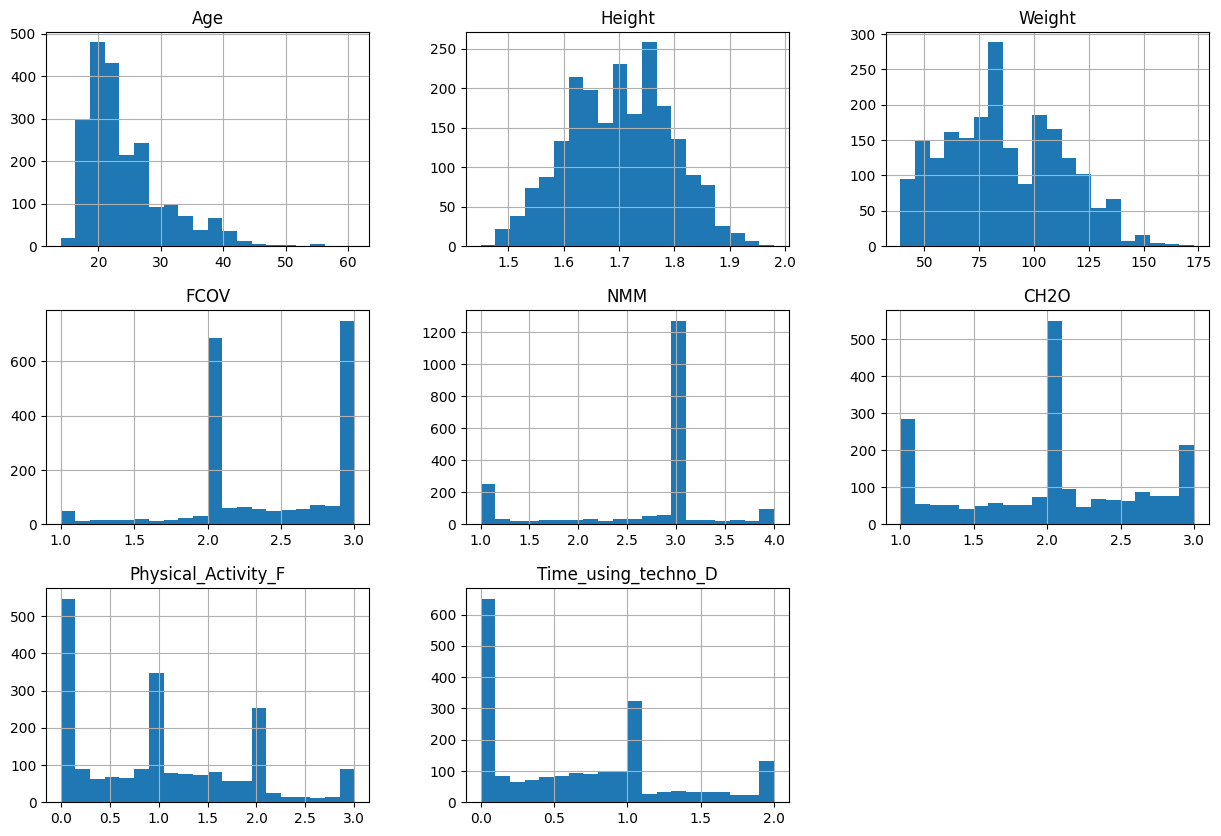

In [18]:
# Plotting histogram
df.hist(figsize=(15,10), bins=20)
plt.show()

The diagrams above illustrate the frequency distribution of various continuous values:  
- The majority of people fall within the age range of 20–30.  
- Physical activity frequency varies, with very few individuals working out daily.  
- Over 1,200 individuals prefer having three main meals per day.  
- The frequency of vegetable consumption is notably high.

**Correlations between continuous varibles**
- **Identify Relationships**: Highlights the strength and direction of linear relationships between variables.
- **Feature Selection**: Helps in identifying redundant or highly correlated features that may impact model performance.
- **Model Insights**: Provides a better understanding of how variables interact and their potential influence on the target variable.
- **Data Understanding**: Reveals trends or dependencies that can guide exploratory data analysis and hypothesis generation.

In [19]:
#correlation matrix for numerical columns
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
correlation_matrix

,Age,Height,Weight,FCOV,NMM,CH2O,Physical_Activity_F,Time_using_techno_D
Age,1.000000,-0.025958,0.202560,0.016291,-0.043944,-0.045304,-0.144938,-0.296931
Height,-0.025958,1.000000,0.463136,-0.038121,0.243672,0.213376,0.294709,0.051912
Weight,0.202560,0.463136,1.000000,0.216125,0.107469,0.200575,-0.051436,-0.071561
FCOV,0.016291,-0.038121,0.216125,1.000000,0.042216,0.068461,0.019939,-0.101135
NMM,-0.043944,0.243672,0.107469,0.042216,1.000000,0.057088,0.129504,0.036326
CH2O,-0.045304,0.213376,0.200575,0.068461,0.057088,1.000000,0.167236,0.011965
Physical_Activity_F,-0.144938,0.294709,-0.051436,0.019939,0.129504,0.167236,1.000000,0.058562
Time_using_techno_D,-0.296931,0.051912,-0.071561,-0.101135,0.036326,0.011965,0.058562,1.000000


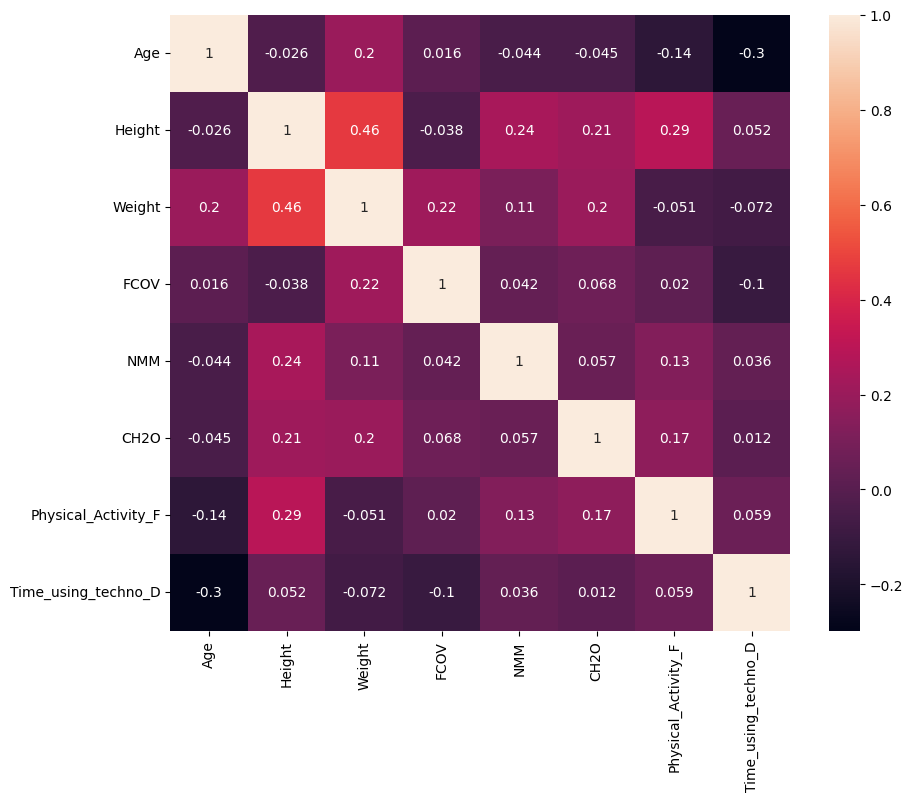

In [20]:
#heatmap of the same
plt.figure(figsize=(10,8))
sns.heatmap(numerical_df.corr(), annot=True)
plt.show()

In [21]:
#To filter out the correlated columns
moderate_threshold = 0.3
high_threshold = 0.7

correlation_pairs = correlation_matrix.unstack()
filtered_correlations = correlation_pairs[(correlation_pairs >= moderate_threshold) & (correlation_pairs != 1)]

filtered_correlations = filtered_correlations.drop_duplicates()

moderate_correlations = filtered_correlations[
    (filtered_correlations >= moderate_threshold) & (filtered_correlations < high_threshold)
]
high_correlations = filtered_correlations[filtered_correlations >= high_threshold]

print("Moderate Correlations:")
print(moderate_correlations)
print("\nHigh Correlations:")
print(high_correlations)


Moderate Correlations:
Height  Weight    0.463136
dtype: float64

High Correlations:
Series([], dtype: float64)


**The correlation heatmap reveals the following:**

**Moderate Positive Correlations**

Weight and Height (0.46): Taller individuals tend to weigh more.
Height and Physical Activity (0.29): Taller individuals may have slightly higher physical activity levels.
Water Consumption (CH2O) and Physical Activity (0.17): Higher physical activity is weakly linked to better hydration habits.

**Weak Negative Correlations**
Age and Time_using_techno_D (-0.3): Younger individuals may spend more time on technology devices.

**Minimal Correlations**
Most variables show weak or near-zero correlations, suggesting minimal linear relationships.

**Conclusion** The dataset lacks strong linear dependencies, indicating that non-linear machine learning models may be better suited for effective obesity prediction

**Box Plots for Numerical Columns**

This code generates box plots for each numerical column in the dataset to visually inspect for outliers.This step is crucial for data preprocessing in machine learning projects as outliers can significantly affect the performance of many models (e.g., regression or distance-based algorithms like k-NN and SVM). Handling outliers appropriately ensures robust model performance.

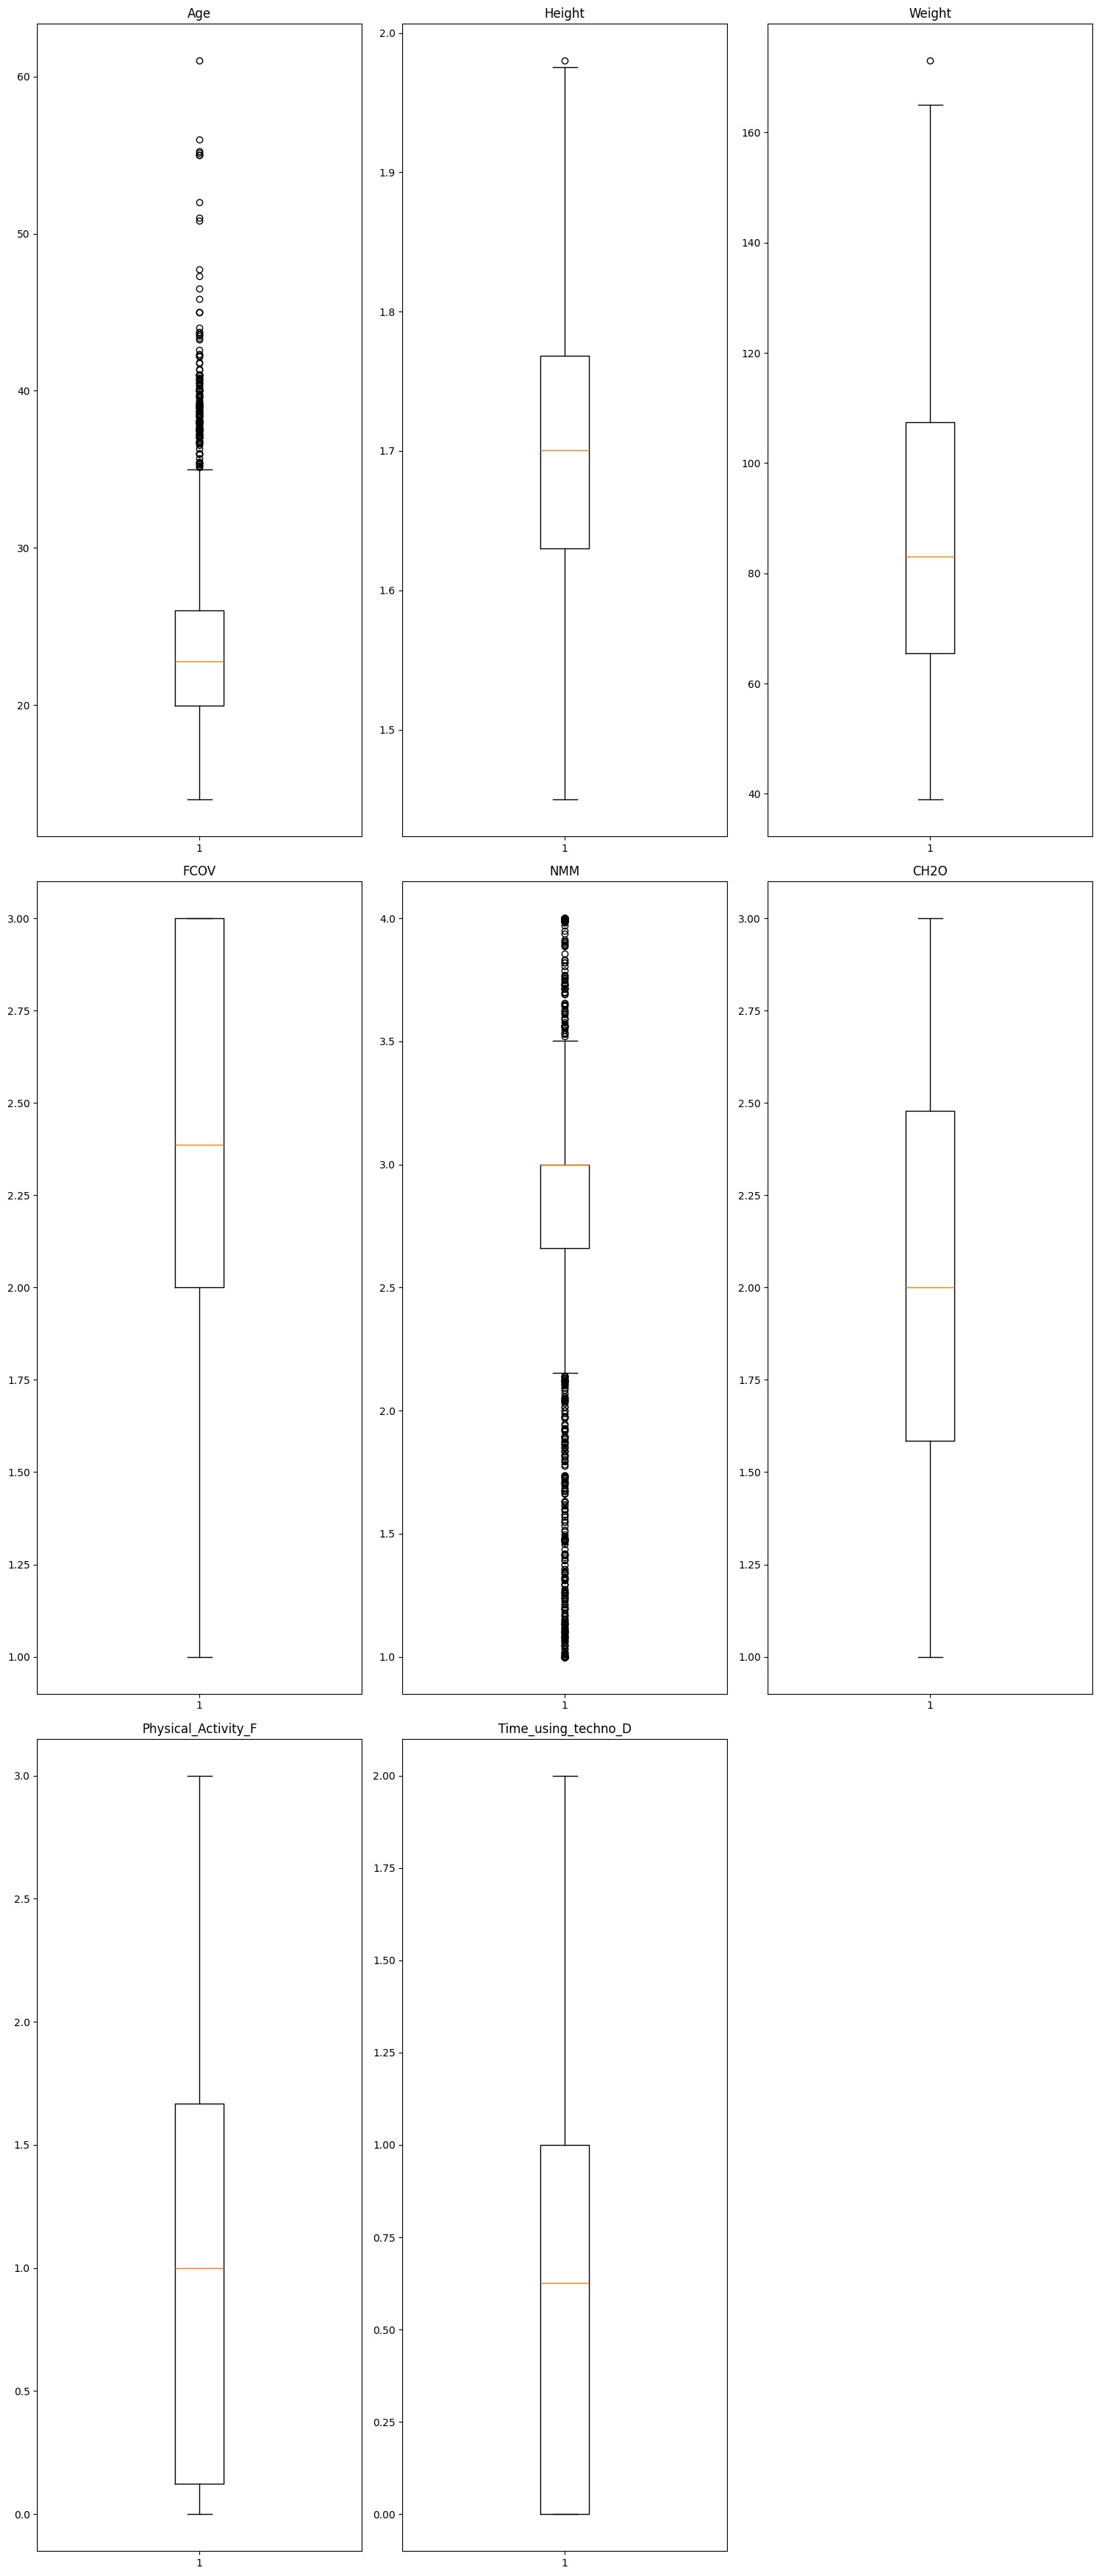

In [22]:
#Box plots for the numerical columns to detect if there any outliers present
numerical_vars = ['Age', 'Height', 'Weight', 'FCOV', 'NMM', 'CH2O',
                  'Physical_Activity_F', 'Time_using_techno_D']

plt.figure(figsize=(15, 35))

for i, column in enumerate(numerical_vars, start=1):
    plt.subplot((len(numerical_vars) + 2) // 3, 3, i)
    plt.boxplot(df[column].dropna())
    plt.title(column)

plt.tight_layout()
plt.show()


We have outliers present in number of meals(NMM), Height, weight and Age column.
We will have to handle these outliners in pre-processing stage.

**Count Plots for cateogorical variables**

This code generates count plots for each categorical variable in the dataset to visualize the distribution of classes and detect potential class imbalances.


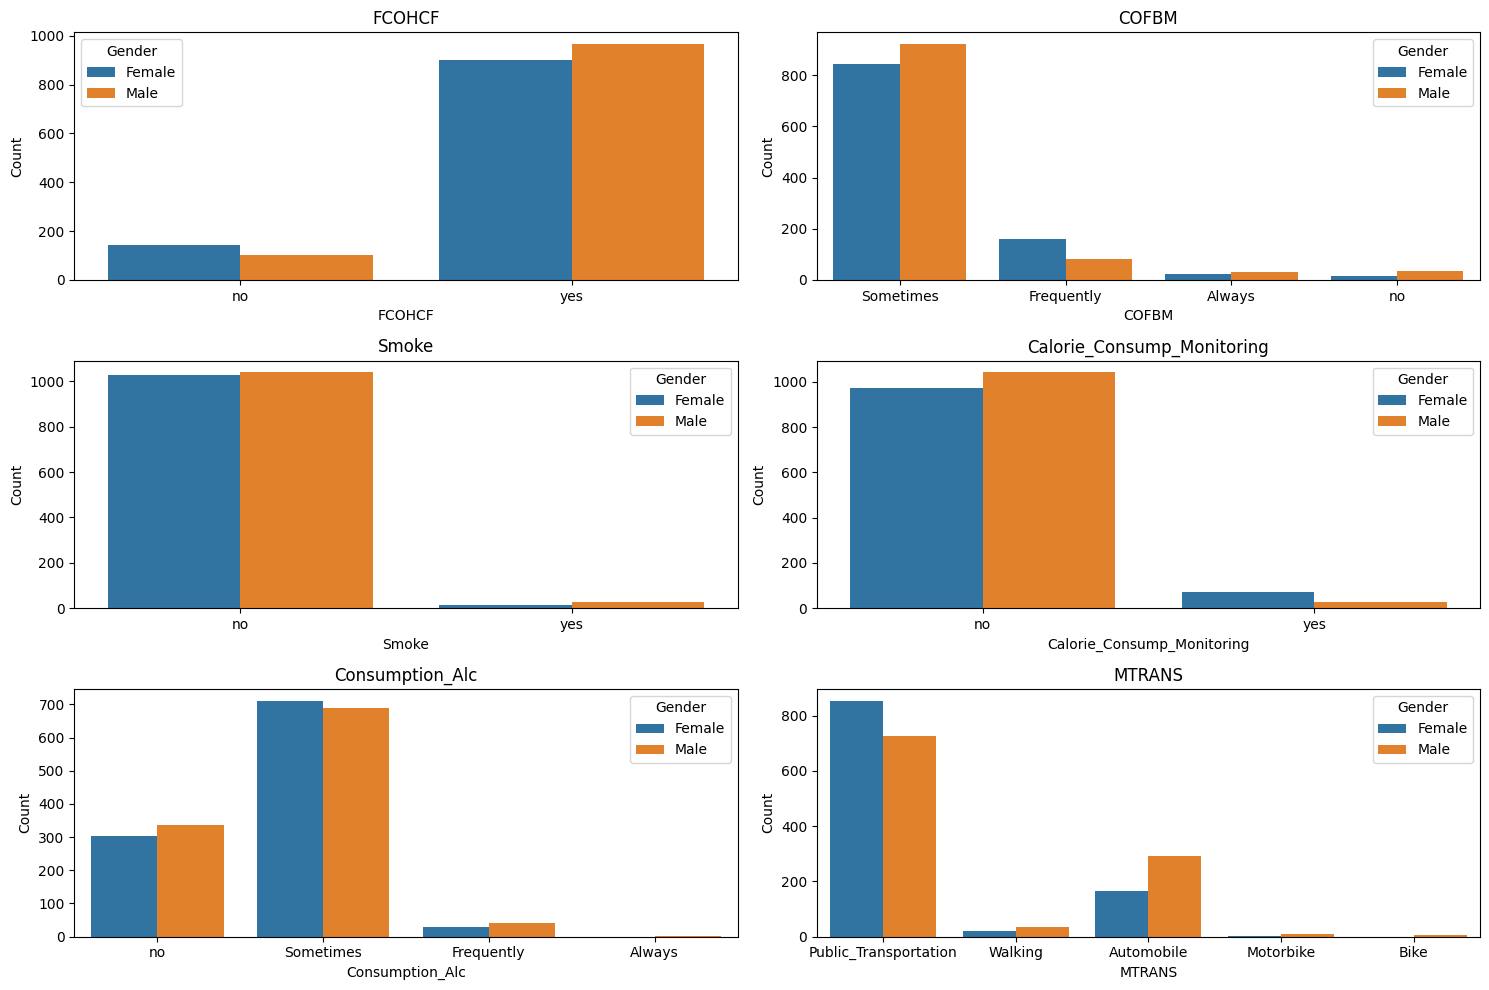

In [23]:
#Countplots for each cateogorical variables to check if there any class imbalances
categorical_vars = ['FCOHCF', 'COFBM', 'Smoke', 'Calorie_Consump_Monitoring',
                    'Consumption_Alc', 'MTRANS']

plt.figure(figsize=(15, 10))

for i, column in enumerate(categorical_vars, start=1):
    plt.subplot((len(categorical_vars) + 1) // 2, 2, i)
    sns.countplot(data=df, x=column, hue='Gender')
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

The countplot shows categorical data based on age:
- Both males and females frequently consume high-calorie food.
- Public transportation is the preferred mode of travel for both genders.
- Only a small number of people monitor their calorie intake.
- Over 1,600 people enjoy snacking between main meals.

**Violin Plots for Numerical variables**

A violin plot displays the distribution of numerical data, combining box plots and density plots. It shows the data’s frequency distribution, central tendency, and spread, making it useful for comparing categories.

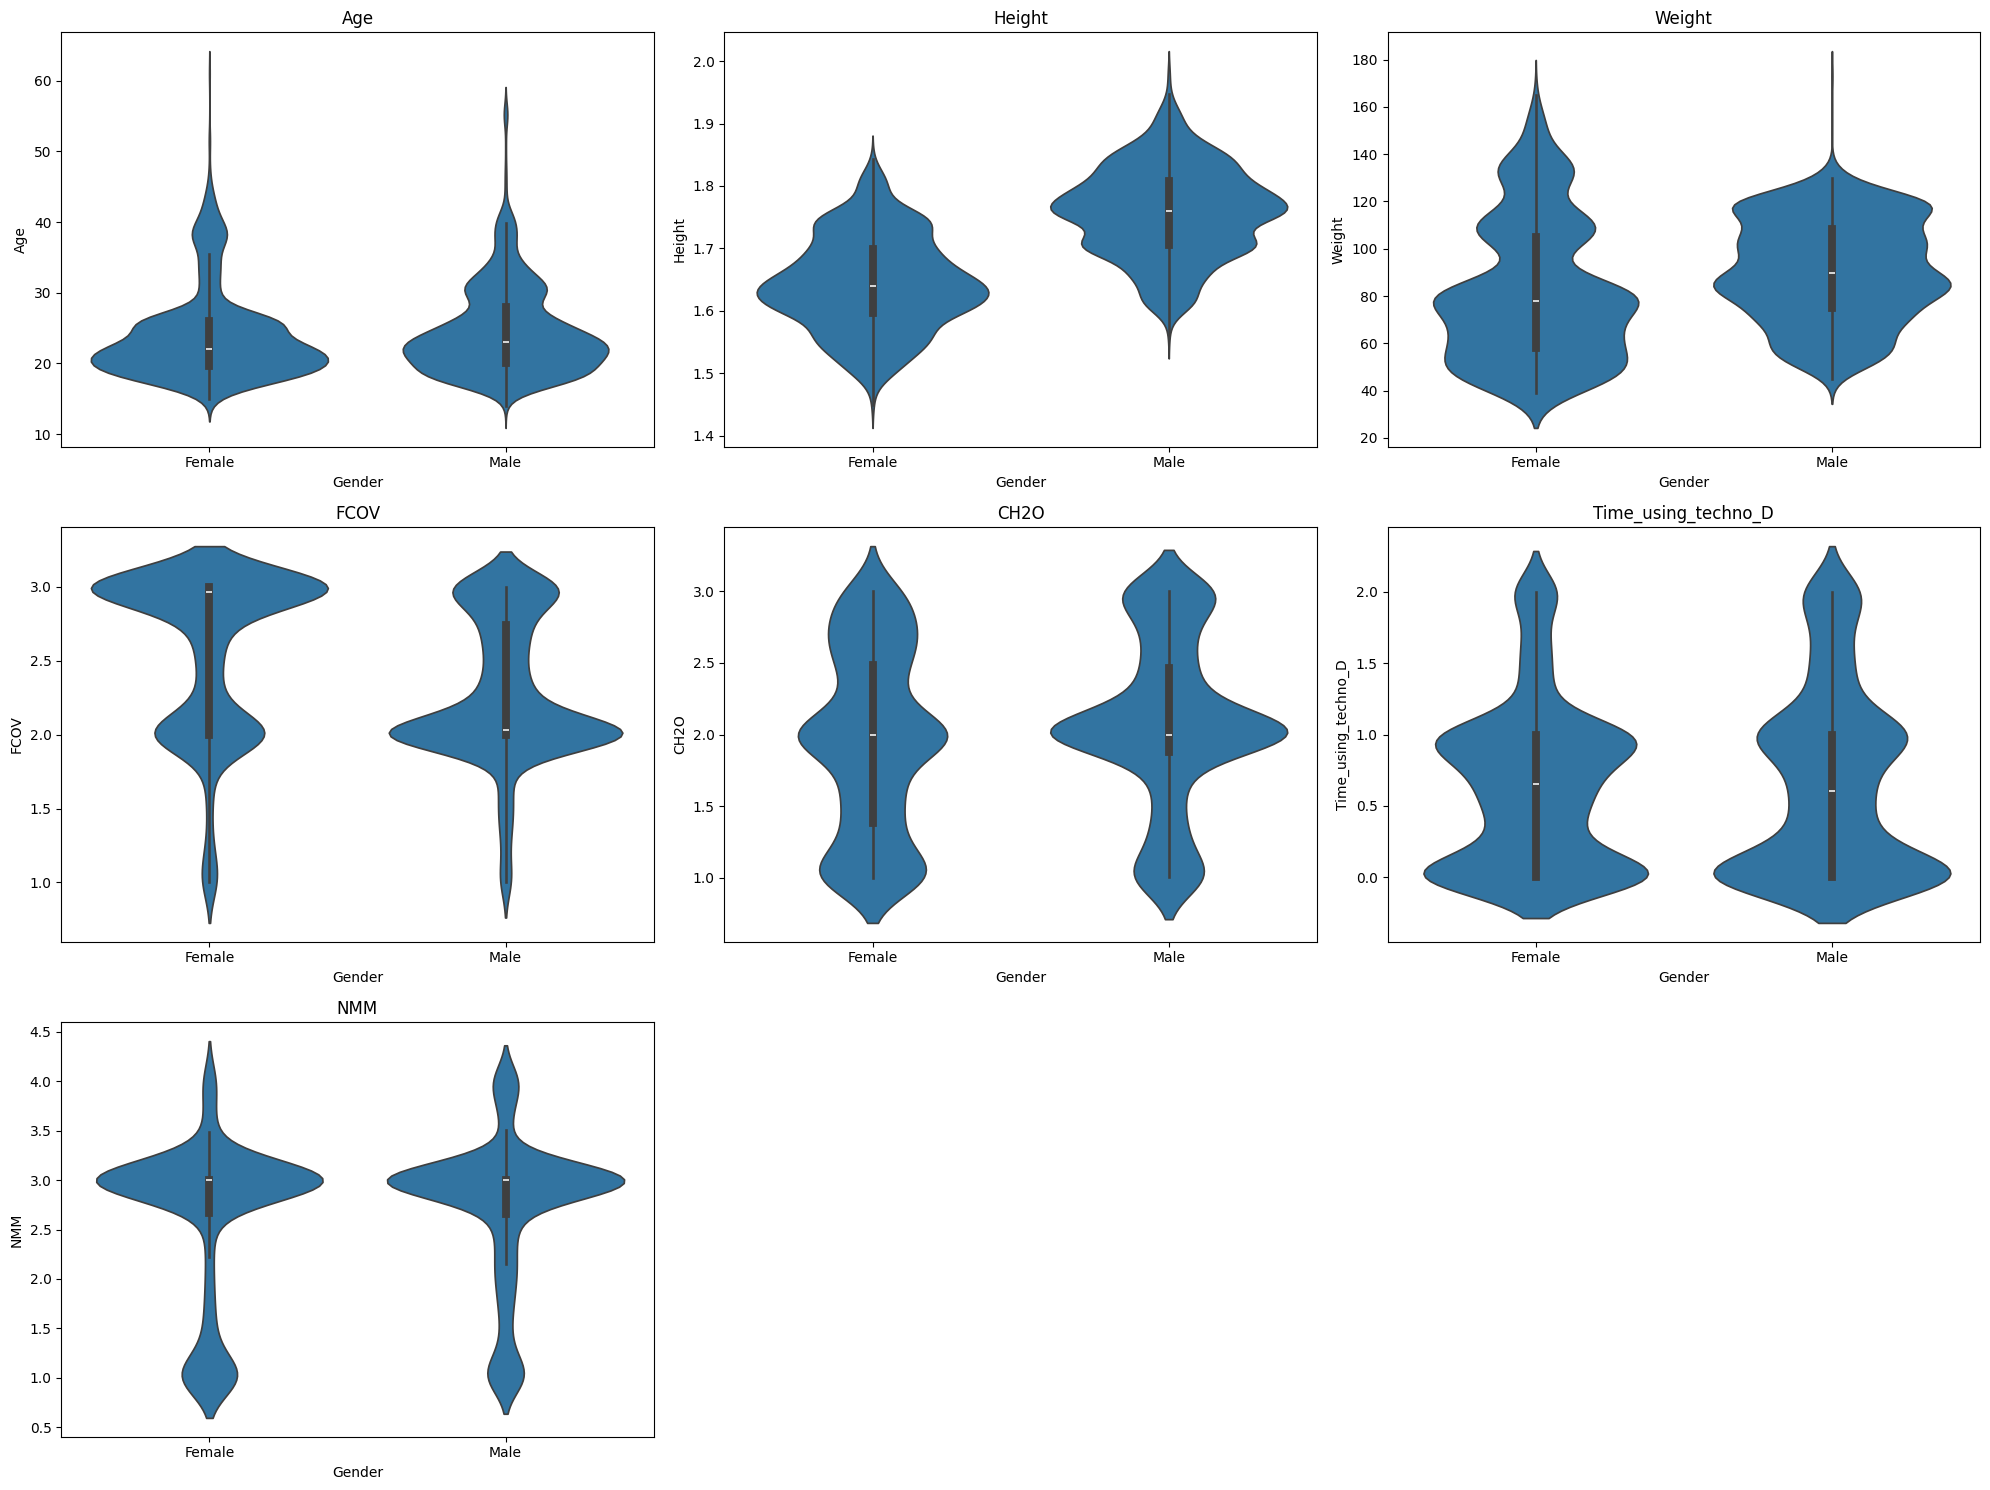

In [24]:
#To check skewness for the same
continuous_vars = ['Age', 'Height', 'Weight', 'FCOV', 'CH2O',
                   'Time_using_techno_D', 'NMM']

plt.figure(figsize=(20, 15))

for i, column in enumerate(continuous_vars, start=1):
    plt.subplot((len(continuous_vars) + 2) // 3, 3, i)
    sns.violinplot(x='Gender', y=column, data=df)
    plt.title(column)
    plt.xlabel('Gender')
    plt.ylabel(column)

plt.tight_layout()
plt.show()


 We can see high skewness in age and number of main meals variable. We will remove this skewness using IQR in preprocessing.

**Class Distribution of the Target Variable**

The following pie chart visualizes the distribution of the target variable, NObesity, across different obesity categories. The chart shows the percentage of instances in each class.

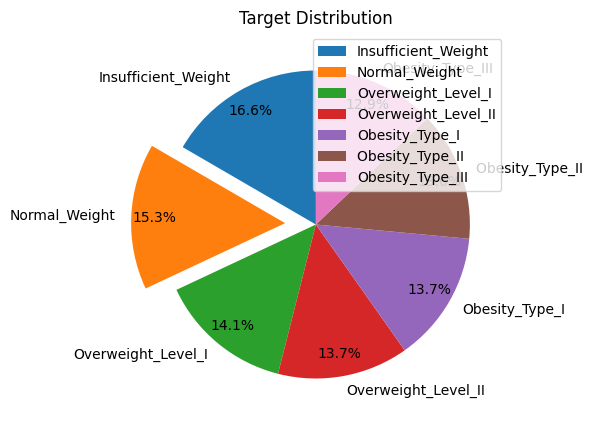

In [25]:
#Class distribution of the target variable
plt.figure(figsize=(5, 5))
myexplode = [ 0, 0.2, 0, 0, 0, 0, 0]
plt.pie(df['NObesity'].value_counts(), labels=['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II ', 'Obesity_Type_III'],
        autopct='%1.1f%%', startangle=90, pctdistance=0.85, explode=myexplode)
plt.legend(loc='upper right')
plt.title("Target Distribution")
plt.show()

We can see that there is all output classes are balanced. Hence, we can use type of sampling we want.

# Data Pre-processing

## Handling missing and duplicate values

This ensures the dataset is clean and ready by removing any duplicate records and handling missing data appropriately.

In [26]:
df.shape

(2111, 17)

In [27]:
df.duplicated().any()
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 24


In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df.shape

(2087, 17)

## Handling Outliners

This code removes outliers from numerical columns in a DataFrame using the Interquartile Range (IQR) method and replaces them with the column's median value, preserving data integrity and reducing the impact of extreme values. It is a key step in data preprocessing for machine learning workflows to ensure models are trained on clean, consistent, and reliable data.

In [30]:
#To remove outliers based on inter quartile range for each column
for columns in df.columns:
    if df[columns].dtype == object :
        continue
    else:
        Q1 = df[columns].quantile(q=0.25)
        Q3 = df[columns].quantile(q=0.75)
        iqr = Q3-Q1

        low = Q1 - 1.5*(Q3-Q1)
        high = Q3 + 1.5*(Q3-Q1)
        df.loc[(df[columns]<low) | (df[columns]>high),columns] = df[columns].median()

## Feature Scaling

This code scales all numerical features in the dataset using StandardScaler from sklearn, which standardizes the data. This ensures all features are on the same scale, improving model performance and analysis.

In [31]:
#scaling all the features for better analysis
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[df.select_dtypes(include=['int','float']).columns] = scaler.fit_transform(df[df.select_dtypes(include=['int','float']).columns])
df.head()

,Gender,Age,Height,Weight,Family_history_with_overweight,FCOHCF,FCOV,NMM,COFBM,Smoke,CH2O,Calorie_Consump_Monitoring,Physical_Activity_F,Time_using_techno_D,Consumption_Alc,MTRANS,NObesity
0,Female,-0.473866,-0.887864,-0.873605,yes,no,-0.788364,0.183899,Sometimes,no,-0.007810,no,-1.186977,0.554211,no,Public_Transportation,Normal_Weight
1,Female,-0.473866,-1.963531,-1.179922,yes,no,1.082164,0.183899,Sometimes,yes,1.636552,yes,2.328908,-1.090505,Sometimes,Public_Transportation,Normal_Weight
2,Male,0.007852,1.048338,-0.375838,yes,no,-0.788364,0.183899,Sometimes,no,-0.007810,no,1.156947,0.554211,Frequently,Public_Transportation,Normal_Weight
3,Male,0.971287,1.048338,0.007059,no,no,1.082164,0.183899,Sometimes,no,-0.007810,no,1.156947,-1.090505,Frequently,Walking,Overweight_Level_I
4,Male,-0.233007,0.833204,0.114270,no,no,-0.788364,0.183899,Sometimes,no,-0.007810,no,-1.186977,-1.090505,Sometimes,Public_Transportation,Overweight_Level_II


In [32]:
scaled = pd.DataFrame(df[df.select_dtypes(include=['int','float']).columns])
scaled.columns = list(df.select_dtypes(include=['int','float']).columns)
print(scaled.describe())

                Age        Height        Weight          FCOV           NMM  \
count  2.087000e+03  2.087000e+03  2.087000e+03  2.087000e+03  2.087000e+03   
mean  -6.809226e-16  1.252898e-15  3.268428e-16 -5.447381e-16  7.285872e-16   
std    1.000240e+00  1.000240e+00  1.000240e+00  1.000240e+00  1.000240e+00   
min   -2.159878e+00 -2.716498e+00 -1.830847e+00 -2.658892e+00 -5.711137e+00   
25%   -7.349721e-01 -7.783768e-01 -7.970251e-01 -7.883642e-01  1.838990e-01   
50%   -2.885077e-02 -1.029110e-02 -1.422292e-01 -4.713949e-02  1.838990e-01   
75%    6.196666e-01  7.192481e-01  8.113835e-01  1.082164e+00  1.838990e-01   
max    2.928363e+00  2.937888e+00  2.995848e+00  1.082164e+00  3.770540e+00   

               CH2O  Physical_Activity_F  Time_using_techno_D  
count  2.087000e+03         2.087000e+03         2.087000e+03  
mean   4.085536e-16         2.587506e-16        -1.089476e-16  
std    1.000240e+00         1.000240e+00         1.000240e+00  
min   -1.652172e+00        -1.18

## Catagorical features factoring

This code converts categorical variables in the DataFrame to numerical format by factoring each category

In [33]:
df.dtypes=='object'

,0
Gender,True
Age,False
Height,False
Weight,False
Family_history_with_overweight,True
FCOHCF,True
FCOV,False
NMM,False
COFBM,True
Smoke,True


In [34]:
df['Gender'], c =pd.factorize(df['Gender'])
df['Family_history_with_overweight'], c = pd.factorize(df['Family_history_with_overweight'])
df['FCOHCF'], c = pd.factorize(df['FCOHCF'])
df['Smoke'], c = pd.factorize(df['Smoke'])
df['Calorie_Consump_Monitoring'], c = pd.factorize(df['Calorie_Consump_Monitoring'])

In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['NObesity'] = le.fit_transform(df['NObesity'])
df['COFBM'] = le.fit_transform(df['COFBM'])
df['Consumption_Alc'] = le.fit_transform(df['Consumption_Alc'])
df['MTRANS'] = le.fit_transform(df['MTRANS'])

In [36]:
df['NObesity']

,NObesity
0,1
1,1
2,1
3,5
4,6
...,...
2106,4
2107,4
2108,4
2109,4


## Feature Selection

This code selects the most important features for predicting obesity levels using a Decision Tree Classifier. This code identifies and selects the most relevant features for predicting obesity levels based on their importance as determined by the Decision Tree. It reduces dimensionality, improves model interpretability, and helps focus on the most impactful predictors.

In [37]:
X = df.iloc[:,:-1]
y = df['NObesity']

In [38]:
from sklearn.tree import DecisionTreeClassifier
FS_dt = DecisionTreeClassifier(max_depth=10).fit(X, y)

In [39]:
feature_select = pd.DataFrame()
feature_select['Features'] = X.columns
feature_select['feature_importances_'] = FS_dt.feature_importances_
feature_select.sort_values(by='feature_importances_', ascending=False)

,Features,feature_importances_
3,Weight,0.473302
2,Height,0.220364
0,Gender,0.161920
1,Age,0.044772
14,Consumption_Alc,0.024145
5,FCOHCF,0.019895
6,FCOV,0.016394
8,COFBM,0.012494
13,Time_using_techno_D,0.006353
10,CH2O,0.005841


In [40]:
threshold = 0.003

important_features = feature_select[feature_select['feature_importances_'] >= threshold]
important_features_sorted = important_features.sort_values(by='feature_importances_', ascending=False)
selected_features = important_features_sorted['Features'].tolist()

print("Selected and sorted features:", selected_features)

Selected and sorted features: ['Weight', 'Height', 'Gender', 'Age', 'Consumption_Alc', 'FCOHCF', 'FCOV', 'COFBM', 'Time_using_techno_D', 'CH2O', 'MTRANS', 'Physical_Activity_F', 'Smoke']


We now got which features are actually important for this data. We have considered a threshold of 0.003 and filtered out the important features.

## Train and Test Split

This ensures that the model is trained on 80% of the data and tested on the remaining 20%. Providing a good balance between training and evaluation, with a fixed random state of 40 for reproducibility.

In [41]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X[selected_features], y, test_size=0.2, random_state=40)

# Model Implementation

In [42]:
models = ["Logistic Regression", "K Nearest Neighbour", "Support Vector Machine", "Random Forest", "XG Boost"]
accuracies =[]
import time
model_time = []

## Model 1 - Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [44]:
start_time = time.time()
model_1 = LogisticRegression()
model_1.fit(train_X, train_y)

LogisticRegression()

In [45]:
model1_pred = model_1.predict(test_X)

In [46]:
end_time = time.time()
execution_time = end_time - start_time
model_time.append(execution_time)
print(f"Execution time: {execution_time} seconds")

Execution time: 0.08811831474304199 seconds


In [47]:
model_1_accuracy = accuracy_score(test_y, model1_pred)
accuracies.append(model_1_accuracy)
print('Accuracy:- %0.2f' % model_1_accuracy)

Accuracy:- 0.89


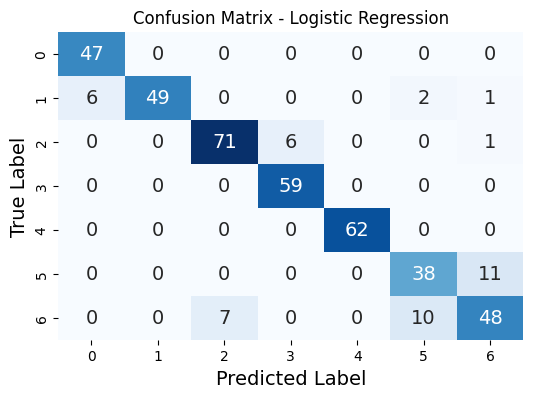

In [48]:
model_1_confusion_matrix = confusion_matrix(test_y, model1_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(model_1_confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title("Confusion Matrix - Logistic Regression", fontsize=12)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()

In [49]:
model_1_CR = classification_report(test_y, model1_pred)
print(model_1_CR)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        47
           1       1.00      0.84      0.92        58
           2       0.91      0.91      0.91        78
           3       0.91      1.00      0.95        59
           4       1.00      1.00      1.00        62
           5       0.76      0.78      0.77        49
           6       0.79      0.74      0.76        65

    accuracy                           0.89       418
   macro avg       0.89      0.90      0.89       418
weighted avg       0.90      0.89      0.89       418



In [50]:
model_1_CR = classification_report(test_y, model1_pred, output_dict=True)
model_1_metrics = model_1_CR['weighted avg']
print(model_1_CR)

{'0': {'precision': 0.8867924528301887, 'recall': 1.0, 'f1-score': 0.94, 'support': 47.0}, '1': {'precision': 1.0, 'recall': 0.8448275862068966, 'f1-score': 0.9158878504672897, 'support': 58.0}, '2': {'precision': 0.9102564102564102, 'recall': 0.9102564102564102, 'f1-score': 0.9102564102564102, 'support': 78.0}, '3': {'precision': 0.9076923076923077, 'recall': 1.0, 'f1-score': 0.9516129032258065, 'support': 59.0}, '4': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 62.0}, '5': {'precision': 0.76, 'recall': 0.7755102040816326, 'f1-score': 0.7676767676767676, 'support': 49.0}, '6': {'precision': 0.7868852459016393, 'recall': 0.7384615384615385, 'f1-score': 0.7619047619047619, 'support': 65.0}, 'accuracy': 0.8947368421052632, 'macro avg': {'precision': 0.8930894880972208, 'recall': 0.8955793912866398, 'f1-score': 0.8924769562187194, 'support': 418.0}, 'weighted avg': {'precision': 0.8962216086614153, 'recall': 0.8947368421052632, 'f1-score': 0.893747913295207, 'support': 41

The Logistic Regression model shows strong performance, correctly predicting most instances for classes such as Class 0 (47), Class 2 (71), Class 3 (59), and Class 4 (62).

However, it struggles with some misclassifications, particularly with Class 1 (misclassified as Class 0 and Class 6) and Class 6 (misclassified as Class 2 and Class 5)

## Model 2 - K-nearest-neighbor

In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [52]:
k_values = range(10, 41)
accuracy_scores = []

In [53]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')
    accuracy_scores.append(np.mean(scores))

best_k = k_values[np.argmax(accuracy_scores)]
best_score = max(accuracy_scores)

print(f"The best value of K is: {best_k}")
print(f"Cross-validated accuracy for best K: {best_score:.4f}")

The best value of K is: 10
Cross-validated accuracy for best K: 0.7791


In [54]:
start_time = time.time()
model_2 = KNeighborsClassifier(n_neighbors= 10)
model_2.fit(train_X, train_y)
model_2_pred = model_2.predict(test_X)
end_time = time.time()
execution_time = end_time - start_time
model_time.append(execution_time)
print(f"Execution time: {execution_time} seconds")

Execution time: 0.06841635704040527 seconds


In [55]:
model_2_accuracy = accuracy_score(test_y, model_2_pred)
accuracies.append(model_2_accuracy)
print('KNN accuracy:-%0.2f' % model_2_accuracy)

KNN accuracy:-0.75


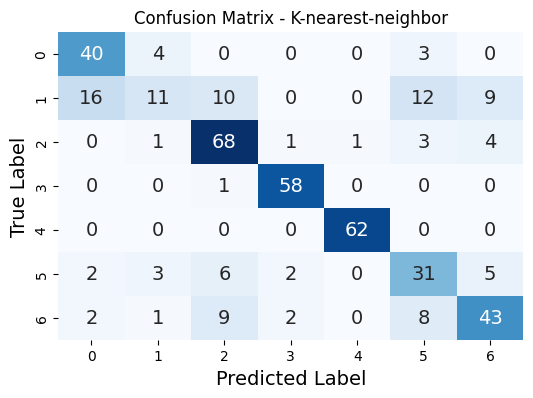

In [56]:
model_2_confusion_matrix = confusion_matrix(test_y, model_2_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(model_2_confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title("Confusion Matrix - K-nearest-neighbor", fontsize=12)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()

In [57]:
model_2_CR = classification_report(test_y, model_2_pred)
print(model_2_CR)

              precision    recall  f1-score   support

           0       0.67      0.85      0.75        47
           1       0.55      0.19      0.28        58
           2       0.72      0.87      0.79        78
           3       0.92      0.98      0.95        59
           4       0.98      1.00      0.99        62
           5       0.54      0.63      0.58        49
           6       0.70      0.66      0.68        65

    accuracy                           0.75       418
   macro avg       0.73      0.74      0.72       418
weighted avg       0.74      0.75      0.73       418



In [58]:
model_2_CR = classification_report(test_y, model_2_pred, output_dict=True)
model_2_metrics = model_2_CR['weighted avg']
print(model_2_CR)

{'0': {'precision': 0.6666666666666666, 'recall': 0.851063829787234, 'f1-score': 0.7476635514018691, 'support': 47.0}, '1': {'precision': 0.55, 'recall': 0.1896551724137931, 'f1-score': 0.28205128205128205, 'support': 58.0}, '2': {'precision': 0.723404255319149, 'recall': 0.8717948717948718, 'f1-score': 0.7906976744186046, 'support': 78.0}, '3': {'precision': 0.9206349206349206, 'recall': 0.9830508474576272, 'f1-score': 0.9508196721311475, 'support': 59.0}, '4': {'precision': 0.9841269841269841, 'recall': 1.0, 'f1-score': 0.992, 'support': 62.0}, '5': {'precision': 0.543859649122807, 'recall': 0.6326530612244898, 'f1-score': 0.5849056603773585, 'support': 49.0}, '6': {'precision': 0.7049180327868853, 'recall': 0.6615384615384615, 'f1-score': 0.6825396825396826, 'support': 65.0}, 'accuracy': 0.7488038277511961, 'macro avg': {'precision': 0.7276586440939161, 'recall': 0.7413937491737826, 'f1-score': 0.7186682175599921, 'support': 418.0}, 'weighted avg': {'precision': 0.735552616075898, '

KNN performs reasonably well for certain classes, like Class 2 (68 correct), Class 4 (62 correct), and Class 3 (58 correct).

However, it struggles with Class 1, where many instances are misclassified, and shows noticeable confusion between Class 5 and Class 6. While the model is effective for some predictions, it has challenges with distinguishing certain classes.

## Model 3 - SVM

We selected kernal as RBF due to the non-linearity observed in the data. The RBF kernel allows the SVM to capture complex relationships between features, making it more suitable for this particular dataset.

In [59]:
from sklearn.svm import SVC

In [60]:
start_time = time.time()
model_3 = SVC()
model_3.fit(train_X, train_y)

SVC()

In [61]:
model_3_pred = model_3.predict(test_X)
end_time = time.time()
execution_time = end_time - start_time
model_time.append(execution_time)
print(f"Execution time: {execution_time} seconds")

Execution time: 0.22583484649658203 seconds


In [62]:
model_3_accuracy = accuracy_score(test_y,model_3_pred)
accuracies.append(model_3_accuracy)
print('SVM accuracy:-%0.2f' % model_3_accuracy)

SVM accuracy:-0.91


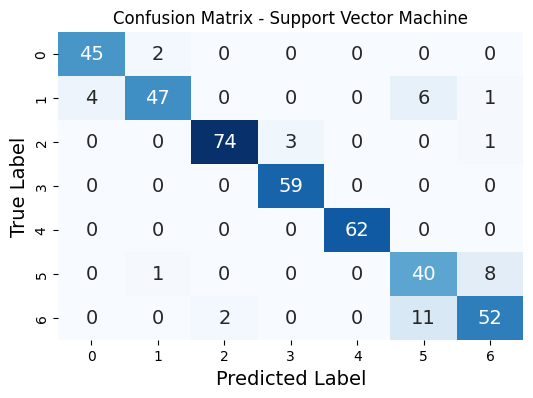

In [63]:
model_3_confusion_matrix = confusion_matrix(test_y, model_3_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(model_3_confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title("Confusion Matrix - Support Vector Machine", fontsize=12)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()

In [64]:
model_3_CR = classification_report(test_y, model_3_pred)
print(model_3_CR)

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        47
           1       0.94      0.81      0.87        58
           2       0.97      0.95      0.96        78
           3       0.95      1.00      0.98        59
           4       1.00      1.00      1.00        62
           5       0.70      0.82      0.75        49
           6       0.84      0.80      0.82        65

    accuracy                           0.91       418
   macro avg       0.90      0.90      0.90       418
weighted avg       0.91      0.91      0.91       418



In [65]:
model_3_CR = classification_report(test_y, model_3_pred, output_dict=True)
model_3_metrics = model_3_CR['weighted avg']
print(model_3_CR)

{'0': {'precision': 0.9183673469387755, 'recall': 0.9574468085106383, 'f1-score': 0.9375, 'support': 47.0}, '1': {'precision': 0.94, 'recall': 0.8103448275862069, 'f1-score': 0.8703703703703703, 'support': 58.0}, '2': {'precision': 0.9736842105263158, 'recall': 0.9487179487179487, 'f1-score': 0.961038961038961, 'support': 78.0}, '3': {'precision': 0.9516129032258065, 'recall': 1.0, 'f1-score': 0.9752066115702479, 'support': 59.0}, '4': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 62.0}, '5': {'precision': 0.7017543859649122, 'recall': 0.8163265306122449, 'f1-score': 0.7547169811320755, 'support': 49.0}, '6': {'precision': 0.8387096774193549, 'recall': 0.8, 'f1-score': 0.8188976377952756, 'support': 65.0}, 'accuracy': 0.9066985645933014, 'macro avg': {'precision': 0.9034469320107378, 'recall': 0.9046908736324342, 'f1-score': 0.9025329374152758, 'support': 418.0}, 'weighted avg': {'precision': 0.9107126530192259, 'recall': 0.9066985645933014, 'f1-score': 0.90730069152471

The SVM model performs well, with most predictions accurate. However, it shows minor misclassifications, particularly between Class 5 and Class 6, where 11 Class 6 instances are predicted as Class 5. Overall, it demonstrates good performance with a scope of improvement.

## Model 4 - Random Forest

In [66]:
from sklearn.ensemble import RandomForestClassifier

In [67]:
start_time = time.time()
model_4 = RandomForestClassifier()
model_4.fit(train_X, train_y)

RandomForestClassifier()

In [68]:
model_4_pred = model_4.predict(test_X)
end_time = time.time()
execution_time = end_time - start_time
model_time.append(execution_time)
print(f"Execution time: {execution_time} seconds")

Execution time: 0.6300601959228516 seconds


In [69]:
model_4_accuracy = accuracy_score(test_y,model_4_pred)
accuracies.append(model_4_accuracy)
print('Random Forest accuracy:-%0.2f' % model_4_accuracy)

Random Forest accuracy:-0.96


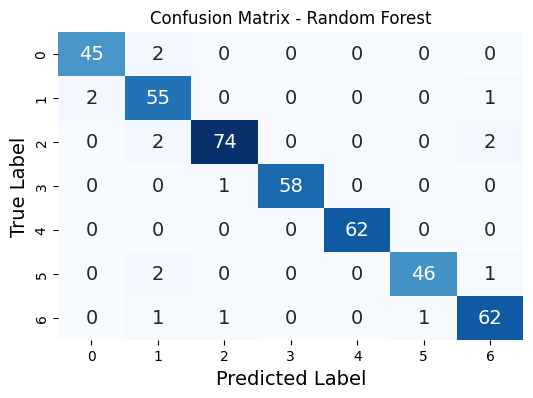

In [70]:
model_4_confusion_matrix = confusion_matrix(test_y, model_4_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(model_4_confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title("Confusion Matrix - Random Forest", fontsize=12)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()

In [71]:
model_4_CR = classification_report(test_y, model_4_pred)
print(model_4_CR)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        47
           1       0.89      0.95      0.92        58
           2       0.97      0.95      0.96        78
           3       1.00      0.98      0.99        59
           4       1.00      1.00      1.00        62
           5       0.98      0.94      0.96        49
           6       0.94      0.95      0.95        65

    accuracy                           0.96       418
   macro avg       0.96      0.96      0.96       418
weighted avg       0.96      0.96      0.96       418



In [72]:
model_4_CR = classification_report(test_y, model_4_pred, output_dict=True)
model_4_metrics = model_4_CR['weighted avg']
print(model_4_CR)

{'0': {'precision': 0.9574468085106383, 'recall': 0.9574468085106383, 'f1-score': 0.9574468085106383, 'support': 47.0}, '1': {'precision': 0.8870967741935484, 'recall': 0.9482758620689655, 'f1-score': 0.9166666666666666, 'support': 58.0}, '2': {'precision': 0.9736842105263158, 'recall': 0.9487179487179487, 'f1-score': 0.961038961038961, 'support': 78.0}, '3': {'precision': 1.0, 'recall': 0.9830508474576272, 'f1-score': 0.9914529914529915, 'support': 59.0}, '4': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 62.0}, '5': {'precision': 0.9787234042553191, 'recall': 0.9387755102040817, 'f1-score': 0.9583333333333334, 'support': 49.0}, '6': {'precision': 0.9393939393939394, 'recall': 0.9538461538461539, 'f1-score': 0.9465648854961832, 'support': 65.0}, 'accuracy': 0.9617224880382775, 'macro avg': {'precision': 0.9623350195542516, 'recall': 0.9614447329722021, 'f1-score': 0.9616433780712533, 'support': 418.0}, 'weighted avg': {'precision': 0.9627201774961607, 'recall': 0.96172

The Random Forest model performs well, accurately predicting the majority of instances(96%) for each class. In general, the model demonstrates strong performance, with only a handful of errors that could be due to overlap or similarities between the classes. This indicates the Random Forest is reliable but could benefit from slight adjustments to handle edge cases better.

## Model 5 - XG Boost

In [73]:
#!pip install xgboost
import xgboost as xgb
from xgboost.sklearn import XGBClassifier
from xgboost import plot_importance

In [74]:
start_time = time.time()
model_5 = XGBClassifier()
model_5.fit(train_X, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [75]:
model_5_pred = model_5.predict(test_X)
end_time = time.time()
execution_time = end_time - start_time
model_time.append(execution_time)
print(f"Execution time: {execution_time} seconds")

Execution time: 0.50136399269104 seconds


In [76]:
model_5_accuracy = accuracy_score(test_y,model_5_pred)
accuracies.append(model_5_accuracy)
print('XG Boost:-%0.2f' % model_5_accuracy)

XG Boost:-0.98


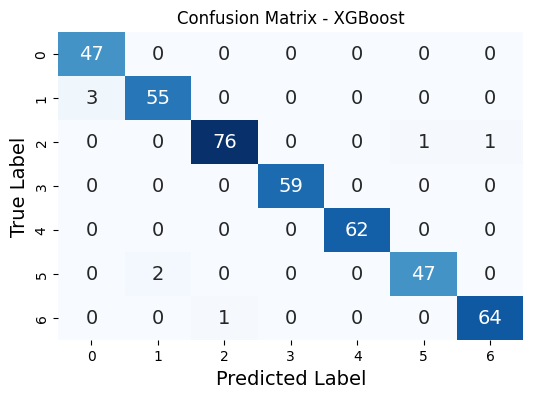

In [77]:
model_5_confusion_matrix = confusion_matrix(test_y, model_5_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(model_5_confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title("Confusion Matrix - XGBoost", fontsize=12)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()

In [78]:
model_5_CR = classification_report(test_y, model_5_pred)
print(model_5_CR)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        47
           1       0.96      0.95      0.96        58
           2       0.99      0.97      0.98        78
           3       1.00      1.00      1.00        59
           4       1.00      1.00      1.00        62
           5       0.98      0.96      0.97        49
           6       0.98      0.98      0.98        65

    accuracy                           0.98       418
   macro avg       0.98      0.98      0.98       418
weighted avg       0.98      0.98      0.98       418



In [79]:
model_5_CR = classification_report(test_y, model_5_pred, output_dict=True)
model_5_metrics = model_5_CR['weighted avg']
print(model_5_CR)

{'0': {'precision': 0.94, 'recall': 1.0, 'f1-score': 0.9690721649484536, 'support': 47.0}, '1': {'precision': 0.9649122807017544, 'recall': 0.9482758620689655, 'f1-score': 0.9565217391304348, 'support': 58.0}, '2': {'precision': 0.987012987012987, 'recall': 0.9743589743589743, 'f1-score': 0.9806451612903225, 'support': 78.0}, '3': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 59.0}, '4': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 62.0}, '5': {'precision': 0.9791666666666666, 'recall': 0.9591836734693877, 'f1-score': 0.9690721649484536, 'support': 49.0}, '6': {'precision': 0.9846153846153847, 'recall': 0.9846153846153847, 'f1-score': 0.9846153846153847, 'support': 65.0}, 'accuracy': 0.9808612440191388, 'macro avg': {'precision': 0.9793867598566848, 'recall': 0.9809191277875302, 'f1-score': 0.979989516419007, 'support': 418.0}, 'weighted avg': {'precision': 0.9811270141970847, 'recall': 0.9808612440191388, 'f1-score': 0.9808600748451242, 'support': 418.

In the Confusion Matrix,
**Diagonal Values:** The majority of predictions are correct (e.g., 47, 55, 76), indicating strong performance.

**Misclassifications:**
- **Class 1:** Misclassified 3 instances as Class 0.
- **Class 2:** Misclassified 1 instance as Class 6.
- **Class 5:** Misclassified 2 instances as Class 1.

**Overall:** Minimal misclassifications, showcasing XGBoost's high accuracy in predicting labels across all classes.

# Model Comparision

Compared the performance of different machine learning models on the dataset using Time, accuracy, precision, Recall and F1 score

In [80]:
metrics = {
    "Model": models,
    "Time": model_time,
    "Accuracy": accuracies,
    "Precision": [model_1_metrics['precision'], model_2_metrics['precision'], model_3_metrics['precision'], model_4_metrics['precision'], model_5_metrics['precision']],
    "Recall": [model_1_metrics['recall'], model_2_metrics['recall'], model_3_metrics['recall'], model_4_metrics['recall'], model_5_metrics['recall']], # Changed 'Recall' to 'recall' for model_2_metrics, model_3_metrics, model_4_metrics, and model_5_metrics
    "F1 Score": [model_1_metrics['f1-score'], model_2_metrics['f1-score'], model_3_metrics['f1-score'], model_4_metrics['f1-score'], model_5_metrics['f1-score']]
    #, "Support": [model_1_metrics['support'], model_2_metrics['support'], model_3_metrics['support'], model_4_metrics['support'], model_5_metrics['support']]
}


metrics_df = pd.DataFrame(metrics)

print(metrics_df)

                    Model      Time  Accuracy  Precision    Recall  F1 Score
0     Logistic Regression  0.088118  0.894737   0.896222  0.894737  0.893748
1     K Nearest Neighbour  0.068416  0.748804   0.735553  0.748804  0.726798
2  Support Vector Machine  0.225835  0.906699   0.910713  0.906699  0.907301
3           Random Forest  0.630060  0.961722   0.962720  0.961722  0.961982
4                XG Boost  0.501364  0.980861   0.981127  0.980861  0.980860


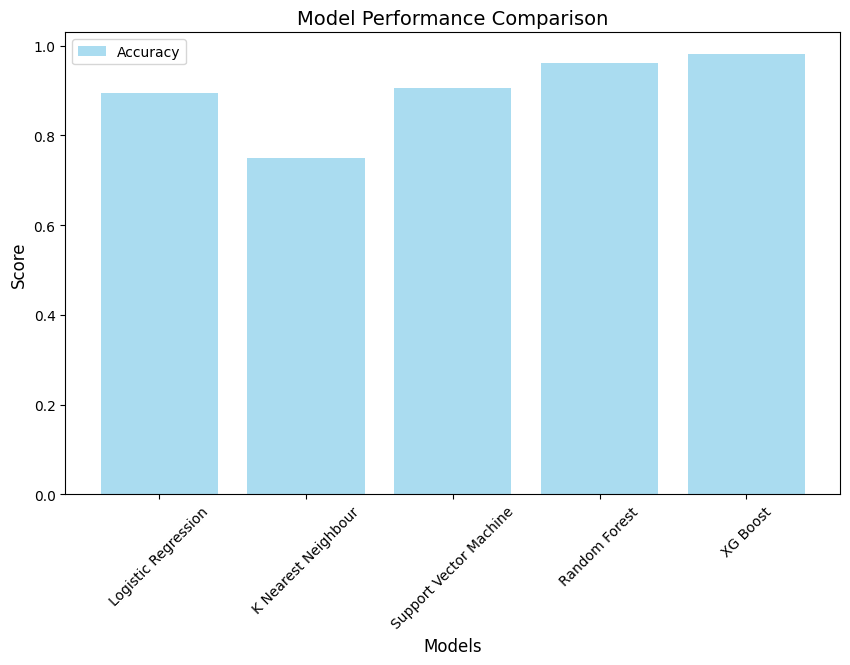

In [81]:
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color='skyblue', alpha=0.7, label='Accuracy')
plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.title('Model Performance Comparison', fontsize=14)
plt.legend()
plt.show()

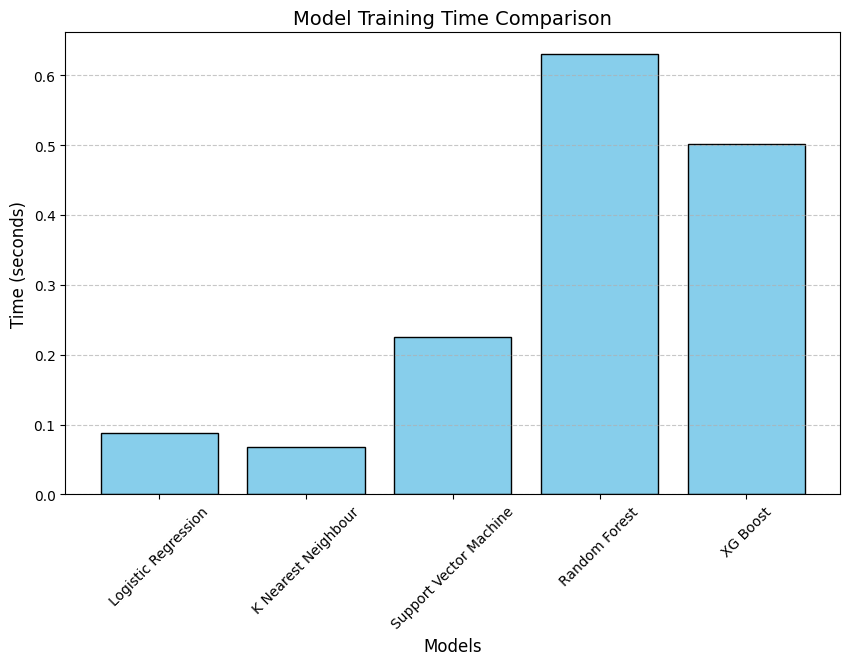

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(models, model_time, color='skyblue', edgecolor='black')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.title('Model Training Time Comparison', fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


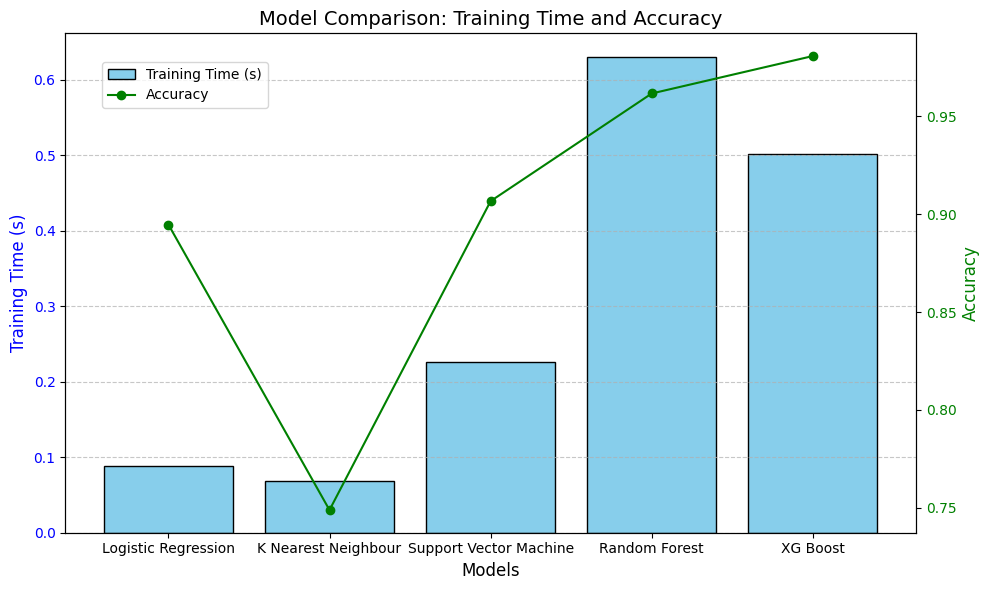

In [83]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(models, model_time, color='skyblue', edgecolor='black', label='Training Time (s)')
ax1.set_xlabel('Models', fontsize=12)
ax1.set_ylabel('Training Time (s)', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(models, accuracies, color='green', marker='o', label='Accuracy')
ax2.set_ylabel('Accuracy', fontsize=12, color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Model Comparison: Training Time and Accuracy', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9), fontsize=10)

plt.tight_layout()
plt.show()


Overall, for the best accuracy, **XGBoost** is the ideal choice, but if computational efficiency is a concern, **Random Forest** or **Suppport Vector Machine** or **Logistic Regression** may be better options.

- **Logistic Regression:** Slowest (~0.4s) due to iterative optimization, indicating potential need for efficiency improvements.
- **KNN:** Fastest training time (~0.05s) due to its non-parametric nature, making it ideal for time-sensitive tasks.
- **SVM:** Moderate (~0.15s), balancing speed and performance.
- **Random Forest:** Longer training times (~0.35s) It involves training multiple decision trees, which increases computational complexity and time.
- **XGBoost:** Longer training times (~0.35s) It is computationally intensive due to gradient boosting, which iteratively trains trees to minimize errors, though it is highly optimized for speed.


**Conclusion:** Choose models based on the trade-off between training time and predictive performance, with KNN being fastest and tree-based models (Random Forest, XGBoost) better for accuracy-focused tasks.